In [1]:
# mount drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%pip install keras_layer_normalization

  Preparing metadata (setup.py) ... done
  Created wheel for keras_layer_normalization: filename=keras_layer_normalization-0.16.0-py3-none-any.whl size=4654 sha256=b38fd55bba1a10c313ab9e631809e96d8c362e6835a043913961ab965473cecc
  Stored in directory: /root/.cache/pip/wheels/ed/3a/4b/21db23c0cc56c4b219616e181f258eb7c57d36cc5d056fae9a
Successfully built keras_layer_normalization


In [3]:
!unzip /content/drive/MyDrive/UCSD_Anomaly_Dataset.v1p2.zip

Streaming output truncated to the last 5000 lines.
  inflating: UCSD_Anomaly_Dataset.v1p2/UCSDped2/Test/Test005_gt/094.bmp  
  inflating: UCSD_Anomaly_Dataset.v1p2/UCSDped2/Test/Test005_gt/095.bmp  
  inflating: UCSD_Anomaly_Dataset.v1p2/UCSDped2/Test/Test005_gt/096.bmp  
  inflating: UCSD_Anomaly_Dataset.v1p2/UCSDped2/Test/Test005_gt/097.bmp  
  inflating: UCSD_Anomaly_Dataset.v1p2/UCSDped2/Test/Test005_gt/098.bmp  
  inflating: UCSD_Anomaly_Dataset.v1p2/UCSDped2/Test/Test005_gt/099.bmp  
  inflating: UCSD_Anomaly_Dataset.v1p2/UCSDped2/Test/Test005_gt/100.bmp  
  inflating: UCSD_Anomaly_Dataset.v1p2/UCSDped2/Test/Test005_gt/101.bmp  
  inflating: UCSD_Anomaly_Dataset.v1p2/UCSDped2/Test/Test005_gt/102.bmp  
  inflating: UCSD_Anomaly_Dataset.v1p2/UCSDped2/Test/Test005_gt/103.bmp  
  inflating: UCSD_Anomaly_Dataset.v1p2/UCSDped2/Test/Test005_gt/104.bmp  
  inflating: UCSD_Anomaly_Dataset.v1p2/UCSDped2/Test/Test005_gt/105.bmp  
  inflating: UCSD_Anomaly_Dataset.v1p2/UCSDped2/Test/Test005_

In [4]:
DATASET_PATH = "UCSD_Anomaly_Dataset.v1p2/UCSDped1/Train"
SINGLE_TEST_PATH = "UCSD_Anomaly_Dataset.v1p2/UCSDped1/Test/Test032"
BATCH_SIZE = 4
EPOCHS = 3
MODEL_PATH = "/content/drive/MyDrive/model_anomaly_detection.keras"

In [5]:
from os import listdir
from os.path import isfile, join, isdir
import numpy as np
from PIL import Image
import tensorflow as tf

def get_clips_by_stride(stride, frames_list, sequence_size):
    clips = []
    sz = len(frames_list)
    clip = np.zeros(shape=(sequence_size, 256, 256, 1))
    cnt = 0
    for start in range(0, stride):
        for i in range(start, sz, stride):
            clip[cnt, :, :, 0] = frames_list[i]
            cnt = cnt + 1
            if cnt == sequence_size:
                clips.append(np.copy(clip))
                cnt = 0
    return clips


def get_training_data():
    """
    Returns
    -------
    list
        A list of training sequences of shape (NUMBER_OF_SEQUENCES,SINGLE_SEQUENCE_SIZE,FRAME_WIDTH,FRAME_HEIGHT,1)
    """
    clips = []
    # loop over the training folders (Train000,Train001,..)
    for f in sorted(listdir(DATASET_PATH)):
        directory_path = join(DATASET_PATH, f)
        if isdir(directory_path):
            all_frames = []
            # loop over all the images in the folder (0.tif,1.tif,..,199.tif)
            for c in sorted(listdir(directory_path)):
                img_path = join(directory_path, c)
                if str(img_path)[-3:] == "tif":
                    img = Image.open(img_path).resize((256, 256))
                    img = np.array(img, dtype=np.float32) / 256.0
                    all_frames.append(img)
            # get the 10-frames sequences from the list of images after applying data augmentation
            for stride in range(1, 3):
                clips.extend(
                    get_clips_by_stride(
                        stride=stride, frames_list=all_frames, sequence_size=10
                    )
                )
    return clips

In [6]:
def get_single_test(path):
    sz = 200
    test = np.zeros(shape=(sz, 256, 256, 1))
    cnt = 0
    for f in sorted(listdir(path)):
        if str(join(path, f))[-3:] == "tif":
            img = Image.open(join(path, f)).resize((256, 256))
            img = np.array(img, dtype=np.float32) / 256.0
            test[cnt, :, :, 0] = img
            cnt = cnt + 1
    return test

In [7]:
import matplotlib.pyplot as plt


def evaluate(model, path):
    test = get_single_test(path)
    sz = test.shape[0] - 10
    sequences = np.zeros((sz, 10, 256, 256, 1))
    # apply the sliding window technique to get the sequences
    for i in range(0, sz):
        clip = np.zeros((10, 256, 256, 1))
        for j in range(0, 10):
            clip[j] = test[i + j, :, :, :]
        sequences[i] = clip

    # get the reconstruction cost of all the sequences
    reconstructed_sequences = model.predict(sequences, batch_size=4)
    sequences_reconstruction_cost = np.array(
        [
            np.linalg.norm(np.subtract(sequences[i], reconstructed_sequences[i]))
            for i in range(0, sz)
        ]
    )
    sa = (
        sequences_reconstruction_cost - np.min(sequences_reconstruction_cost)
    ) / np.max(sequences_reconstruction_cost)
    sr = 1.0 - sa

    # plot the regularity scores
    plt.plot(sr)
    plt.ylabel("regularity score Sr(t)")
    plt.xlabel("frame t")
    plt.show()



In [8]:
# from keras.models import load_model

# loaded_model = load_model(MODEL_PATH)
# evaluate(loaded_model, "/content/UCSD_Anomaly_Dataset.v1p2/UCSDped1/Train/Train001")

# Defining the Model

In [9]:
import keras
from keras.layers import (
    Conv2DTranspose,
    ConvLSTM2D,
    BatchNormalization,
    TimeDistributed,
    Conv2D,
)
from keras.models import Sequential, load_model
from keras_layer_normalization import LayerNormalization
import numpy as np
import tensorflow as tf

In [10]:
training_data = get_training_data()
training_data = np.array(training_data)

In [11]:
model = Sequential()
model.add(
    TimeDistributed(
        Conv2D(128, (11, 11), strides=4, padding="same"),
        batch_input_shape=(None, 10, 256, 256, 1),
    )
)
model.add(LayerNormalization())
model.add(TimeDistributed(Conv2D(64, (5, 5), strides=2, padding="same")))
model.add(LayerNormalization())
model.add(ConvLSTM2D(64, (3, 3), padding="same", return_sequences=True))
model.add(LayerNormalization())
model.add(ConvLSTM2D(32, (3, 3), padding="same", return_sequences=True))
model.add(LayerNormalization())
model.add(ConvLSTM2D(64, (3, 3), padding="same", return_sequences=True))
model.add(LayerNormalization())
model.add(TimeDistributed(Conv2DTranspose(64, (5, 5), strides=2, padding="same")))
model.add(LayerNormalization())
model.add(TimeDistributed(Conv2DTranspose(128, (11, 11), strides=4, padding="same")))
model.add(LayerNormalization())
model.add(TimeDistributed(Conv2D(1, (11, 11), activation="sigmoid", padding="same")))

In [12]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 time_distributed (TimeDist  (None, 10, 64, 64, 128)   15616     
 ributed)                                                        
                                                                 
 layer_normalization (Layer  (None, 10, 64, 64, 128)   256       
 Normalization)                                                  
                                                                 
 time_distributed_1 (TimeDi  (None, 10, 32, 32, 64)    204864    
 stributed)                                                      
                                                                 
 layer_normalization_1 (Lay  (None, 10, 32, 32, 64)    128       
 erNormalization)                                                
                                                                 
 conv_lstm2d (ConvLSTM2D)    (None, 10, 32, 32, 64)    2

In [13]:
model.compile(
        loss="mse", optimizer=tf.keras.optimizers.legacy.Adam(learning_rate=1e-4, decay=1e-5, epsilon=1e-6)
    )


In [14]:
history = model.fit(
        training_data,
        training_data,
        batch_size=BATCH_SIZE,
        epochs=EPOCHS,
        shuffle=False,
    )


Epoch 1/3
340/340 [==============================] - 174s 449ms/step - loss: 0.0104
Epoch 2/3
340/340 [==============================] - 152s 449ms/step - loss: 0.0036
Epoch 3/3
340/340 [==============================] - 153s 449ms/step - loss: 0.0025


In [15]:
model.save(MODEL_PATH)

48/48 [==============================] - 8s 156ms/step


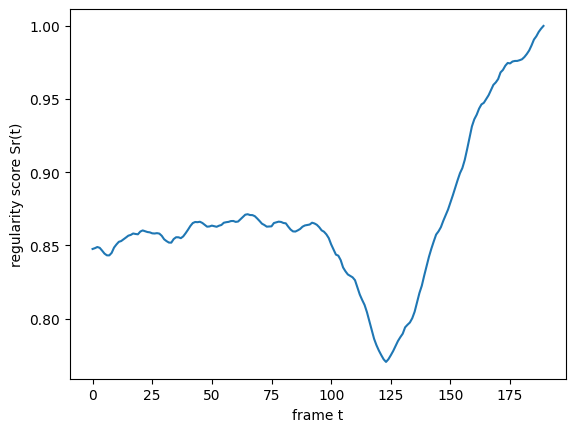

In [17]:
evaluate(model, "/content/UCSD_Anomaly_Dataset.v1p2/UCSDped1/Train/Train001")